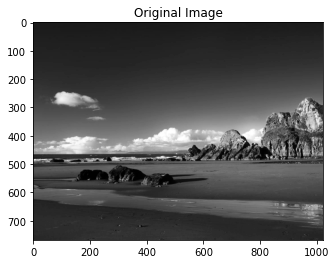

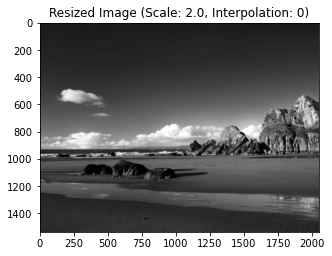

/var/folders/21/cfw5qt6534z4rls8kk90t1480000gq/T/ipykernel_4771/3282085001.py:31: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = 20 * np.log(np.abs(fshift))


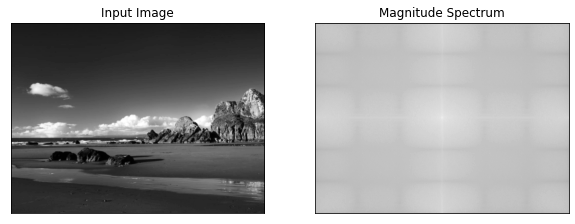

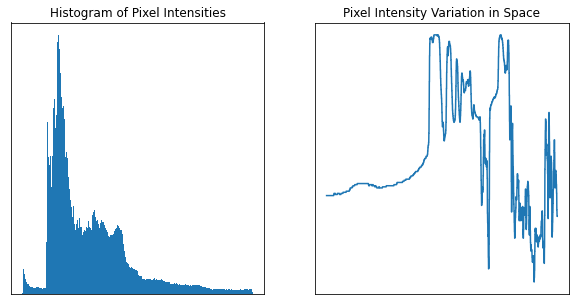

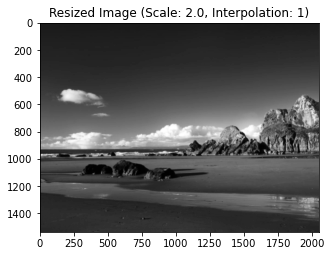

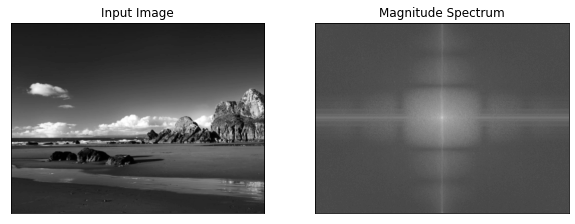

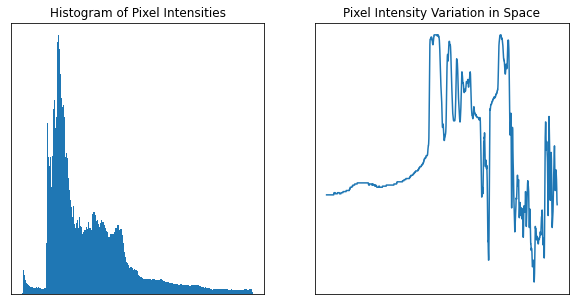

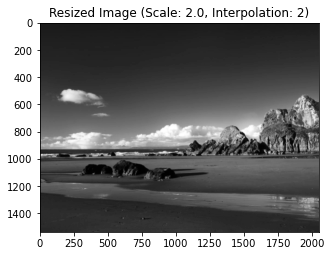

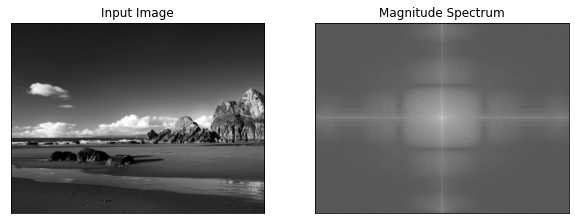

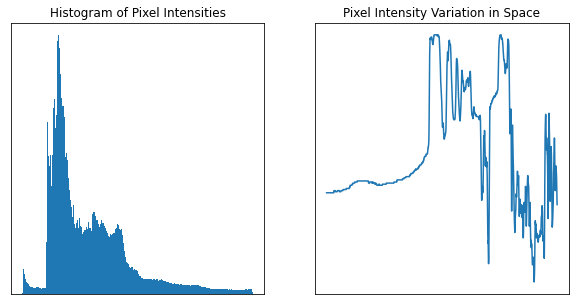

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def resize_image(img, scale_factor, interpolation=cv2.INTER_LINEAR):
    """
    Resize the image with a given scale factor and interpolation technique.
    """
    resized_img = cv2.resize(img, None, fx=scale_factor, fy=scale_factor, interpolation=interpolation)
    return resized_img

def apply_filter(img, filter_type='average', kernel_size=3):
    """
    Apply filtering to the image before resizing.
    """
    if filter_type == 'average':
        kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size ** 2)
        filtered_img = cv2.filter2D(img, -1, kernel)
    elif filter_type == 'gaussian':
        filtered_img = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    else:
        raise ValueError("Invalid filter type. Choose 'average' or 'gaussian'.")
    return filtered_img

def plot_spectral_density(img):
    """
    Plot the spectral density of the image.
    """
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift))

    plt.figure(figsize=(10, 5))
    plt.subplot(121), plt.imshow(img, cmap='gray')
    plt.title('Input Image'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
    plt.show()

def plot_variation_space(img):
    """
    Plot the variation of the signal in space.
    """
    plt.figure(figsize=(10, 5))
    plt.subplot(121), plt.hist(img.ravel(), 256, [0, 256])
    plt.title('Histogram of Pixel Intensities'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.plot(img[img.shape[0] // 2, :])
    plt.title('Pixel Intensity Variation in Space'), plt.xticks([]), plt.yticks([])
    plt.show()

def main():
    # Load the image
    img_path = 'praia_hsv.bmp'  # Replace with your image path
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Display the original image
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.show()

    # Apply filter (optional)
    filtered_img = apply_filter(img, filter_type='average', kernel_size=3)

    # Resize the image with different interpolation techniques
    scale_factors = [2.0]  # Resize by half and double
    interpolation_techniques = [cv2.INTER_NEAREST, cv2.INTER_LINEAR, cv2.INTER_CUBIC]

    for scale_factor in scale_factors:
        for interp in interpolation_techniques:
            resized_img = resize_image(filtered_img, scale_factor, interp)

            # Display the processed image
            plt.figure(figsize=(5, 5))
            plt.imshow(resized_img, cmap='gray')
            plt.title(f'Resized Image (Scale: {scale_factor}, Interpolation: {interp})')
            plt.show()

            # Plot spectral density and variation of the signal in space
            plot_spectral_density(resized_img)
            plot_variation_space(resized_img)

if __name__ == "__main__":
    main()
